In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [2]:
df = pd.read_csv("/content/emails.csv")

# Check data
print(df.head())
print(df.info())

                                                text  spam
0  Subject: naturally irresistible your corporate...     1
1  Subject: the stock trading gunslinger  fanny i...     1
2  Subject: unbelievable new homes made easy  im ...     1
3  Subject: 4 color printing special  request add...     1
4  Subject: do not have money , get software cds ...     1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5728 non-null   object
 1   spam    5728 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 89.6+ KB
None


In [3]:
# Rename columns (optional but cleaner)
df.rename(columns={'text': 'message', 'spam': 'label'}, inplace=True)

# Check null values
print(df.isnull().sum())

# Drop nulls if any
df.dropna(inplace=True)

message    0
label      0
dtype: int64


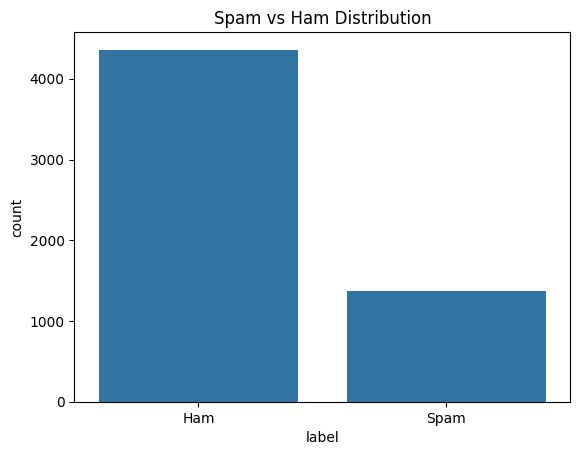

In [10]:
### Spam vs Ham Count

sns.countplot(x='label', data=df)
plt.title("Spam vs Ham Distribution")
plt.xticks([0,1], ['Ham', 'Spam'])
plt.show()

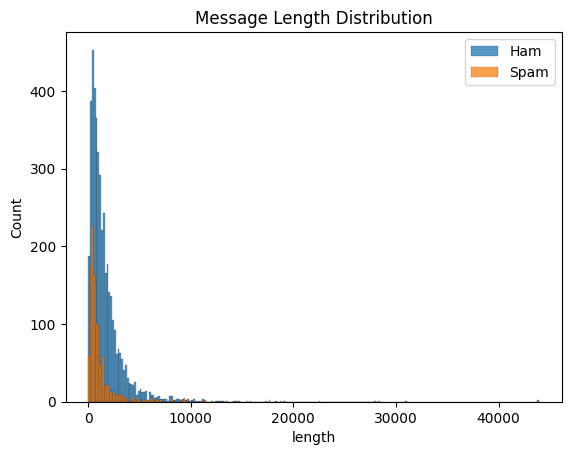

In [11]:
### Message Length Distribution

df['length'] = df['message'].apply(len)

sns.histplot(df[df['label']==0]['length'], label='Ham')
sns.histplot(df[df['label']==1]['length'], label='Spam')

plt.legend()
plt.title("Message Length Distribution")
plt.show()

In [9]:
### Text Preprocessing
nltk.download('stopwords')

ps = PorterStemmer()

def preprocess(text):
    text = text.lower()
    text = re.sub('[^a-z]', ' ', text)
    words = text.split()

    words = [ps.stem(word) for word in words if word not in stopwords.words('english')]

    return " ".join(words)

# Apply preprocessing
df['cleaned_message'] = df['message'].apply(preprocess)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [7]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['cleaned_message']).toarray()
y = df['label']

In [8]:
### Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
### Model Training

model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

Accuracy: 0.9773123909249564


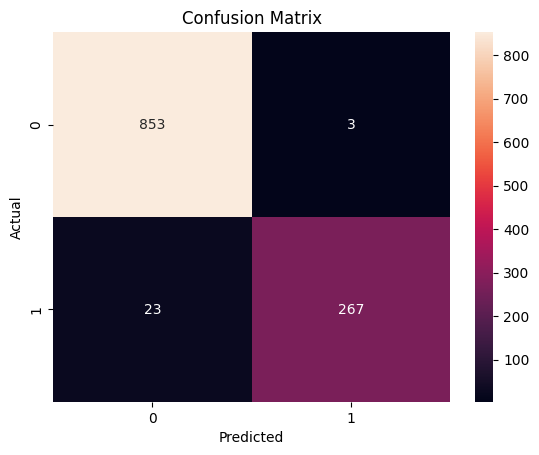

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       856
           1       0.99      0.92      0.95       290

    accuracy                           0.98      1146
   macro avg       0.98      0.96      0.97      1146
weighted avg       0.98      0.98      0.98      1146



In [13]:
### Evaluation

y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Report
print(classification_report(y_test, y_pred))

In [15]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9781849912739965


In [16]:
### Testing the Model with Custom Input

def predict_spam(text):
    text = preprocess(text)
    vector = tfidf.transform([text]).toarray()
    result = model.predict(vector)

    return "Spam" if result[0] == 1 else "Ham"

# Test
print(predict_spam("Get rich fast with this amazing offer!"))

Spam
